In [ ]:
# Real Dataset
#      ↓
# Data Cleaning
#      ↓
# EDA
#      ↓
# Encoding
#      ↓
# Train/Test Split
#      ↓
# Feature Scaling
#      ↓
# Neural Network
#      ↓
# MSE / MAE / R²
#      ↓
# Prediction


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("hour.csv")
print("data imported successfully!")

data imported successfully!


In [5]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


In [8]:
df.columns


Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='str')

In [9]:
print(df.shape)

(17379, 17)


In [10]:
print(df.size)

295443


In [12]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [ ]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
17374    False
17375    False
17376    False
17377    False
17378    False
Length: 17379, dtype: bool

In [ ]:
df = df.drop(columns=["instant", "dteday", "casual", "registered"])

X = df.drop(columns=["cnt"])

y = df["cnt"]

print("X  Shape : ",X.shape)
print("Y  Shape : ",y.shape)

X  Shape :  (17379, 12)
Y  Shape :  (17379,)


In [18]:
print(df.columns)


Index(['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt'],
      dtype='str')


In [ ]:
# Encoding part started
X = pd.get_dummies(
    X,columns=["season","mnth","hr","weekday","weathersit"],
    drop_first=True
)

print(X.head())
print(X.shape)

   yr  holiday  workingday  temp   atemp   hum  windspeed  season_1  season_2  \
0   0        0           0  0.24  0.2879  0.81        0.0      True     False   
1   0        0           0  0.22  0.2727  0.80        0.0      True     False   
2   0        0           0  0.22  0.2727  0.80        0.0      True     False   
3   0        0           0  0.24  0.2879  0.75        0.0      True     False   
4   0        0           0  0.24  0.2879  0.75        0.0      True     False   

   season_3  ...  hr_23  weekday_1  weekday_2  weekday_3  weekday_4  \
0     False  ...  False      False      False      False      False   
1     False  ...  False      False      False      False      False   
2     False  ...  False      False      False      False      False   
3     False  ...  False      False      False      False      False   
4     False  ...  False      False      False      False      False   

   weekday_5  weekday_6  weathersit_2  weathersit_3  weathersit_4  
0      False      

In [30]:
# spliting the data into test and train part 
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)


In [31]:
print(X_train," ",X_test," ",y_train," ",y_test)

       yr  holiday  workingday  temp   atemp   hum  windspeed  season_1  \
335     0        0           0  0.20  0.1970  0.55     0.2239      True   
7035    0        0           1  0.52  0.5000  0.42     0.1045     False   
8051    0        0           1  0.46  0.4545  1.00     0.2239     False   
2133    0        0           0  0.46  0.4545  0.31     0.0000     False   
8485    0        0           0  0.20  0.2273  0.75     0.1045      True   
...    ..      ...         ...   ...     ...   ...        ...       ...   
11284   1        0           1  0.46  0.4545  0.88     0.0896     False   
11964   1        0           1  0.66  0.6212  0.34     0.1343     False   
5390    0        0           1  0.80  0.7273  0.43     0.2836     False   
860     0        0           1  0.24  0.1970  0.65     0.4179      True   
15795   1        0           1  0.52  0.5000  0.83     0.1642     False   

       season_2  season_3  ...  hr_23  weekday_1  weekday_2  weekday_3  \
335       False     False

In [32]:
# feature scaling 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (13903, 54)
X_test: (3476, 54)


In [33]:
print(type(X_train))
print(type(X_test))

print("X_train first value:", X_train[0])
print("X_test first value:", X_test[0])

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
X_train first value: [-1.00410827 -0.17189183 -1.45628403 -1.54083688 -1.62031134 -0.3994488
  0.27866867  1.77034077 -0.5813646  -0.59255176 -0.57062266 -0.28758275
 -0.30552735 -0.2984371  -0.3044003  -0.29858001 -0.30707261 -0.30861278
 -0.29858001 -0.30454133 -0.30086027 -0.30524585 -0.20902252 -0.21014452
 -0.19907811 -0.20638478 -0.20902252 -0.20714128 -0.20543587 -0.20958415
 -0.20939708 -0.20939708  4.79709181 -0.21051742 -0.21163284 -0.20733004
 -0.20883503 -0.21126157 -0.21051742 -0.20751866 -0.20958415 -0.20827172
 -0.2086474  -0.21014452 -0.20920987 -0.40835106 -0.40294045 -0.40619057
 -0.40787138 -0.40583001  2.42261659 -0.59720596 -0.2975787  -0.01199477]
X_test first value: [ 0.99590854 -0.17189183 -1.45628403  1.56781745  1.2815693  -1.85177419
  0.03416424 -0.564863   -0.5813646   1.68761628 -0.57062266 -0.28758275
 -0.30552735 -0.2984371  -0.3044003   3.34918609 -0.30707261 -0.30861278
 -0.29858001 -0.30454133 -0.3008602

In [35]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [36]:
model = Sequential([
    Dense(64,activation="relu",input_shape=(X_train.shape[1],)),
    Dense(32,activation="relu"),
    Dense(16,activation="relu"),
    Dense(1 , activation="linear")
])

C:\Users\Asus Tuf\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [39]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,145 (24.00 KB)

 Trainable params: 6,145 (24.00 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32
)

Epoch 1/50


348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 612.5377 - mae: 16.9801 - val_loss: 2125.9329 - val_mae: 27.9150
Epoch 2/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 602.3211 - mae: 16.7844 - val_loss: 2198.0010 - val_mae: 28.4723
Epoch 3/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 609.3428 - mae: 16.9427 - val_loss: 2167.1511 - val_mae: 27.8463
Epoch 4/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 603.0189 - mae: 16.8537 - val_loss: 2200.0496 - val_mae: 28.2891
Epoch 5/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 607.7766 - mae: 16.9941 - val_loss: 2147.5339 - val_mae: 28.1781
Epoch 6/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 614.1595 - mae: 17.0059 - val_loss: 2208.4434 - val_mae: 28.4610
Epoch 7/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 596.0622 - mae: 16.7797 - val_loss: 2132.9570 - val_mae: 28.0587
Epoch 8/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 588.3506 - mae: 16.7115 - val_loss: 2142.5881 - val_mae: 28.0955
Epoch 9/50


In [53]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 642us/step
R² Score: 0.936801552772522


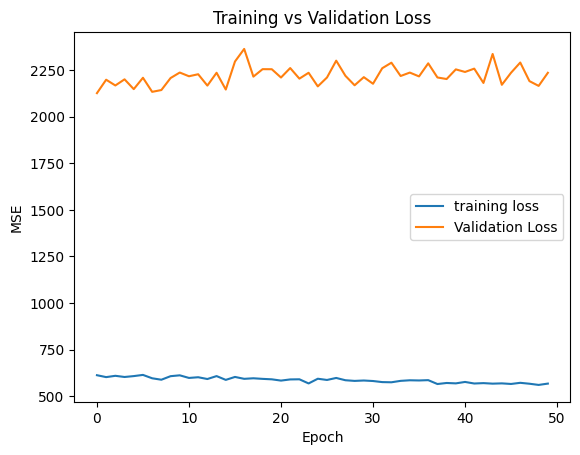

In [54]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"],label = "training loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [56]:
# Above graph tell us that our model is working best on training data but not on validation data or unseen data 
# Overfiitting problem 
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [57]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 563.5378 - mae: 16.3310 - val_loss: 2229.0669 - val_mae: 28.4198
Epoch 2/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 564.4985 - mae: 16.3696 - val_loss: 2232.7458 - val_mae: 28.4464
Epoch 3/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 555.2800 - mae: 16.2947 - val_loss: 2216.4648 - val_mae: 28.2843
Epoch 4/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 560.4780 - mae: 16.3043 - val_loss: 2239.6519 - val_mae: 28.7144
Epoch 5/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 568.6750 - mae: 16.4189 - val_loss: 2339.0500 - val_mae: 29.2256
Epoch 6/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 557.2086 - mae: 16.2960 - val_loss: 2416.8059 - val_mae: 29.5327
Epoch 7/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 562.1638 - mae: 16.3763 - val_loss: 2295.6428 - val_mae: 29.2891
Epoch 8/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 558.4771 - mae: 16.2708 - val_loss: 2215.7871 - val_mae: 28.4559


In [58]:
print("Training completed.")
print("Best validation loss:", min(history.history["val_loss"]))
print("Epochs trained:", len(history.history["loss"]))

Training completed.
Best validation loss: 2202.48681640625
Epochs trained: 16


In [59]:
test_loss, test_mae = model.evaluate(X_test, y_test)

print("Test MSE:", test_loss)
print("Test MAE:", test_mae)

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 919us/step - loss: 1982.1880 - mae: 28.2117
Test MSE: 1982.18798828125
Test MAE: 28.211713790893555


In [60]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 763us/step
R² Score: 0.9374021291732788


In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on unseen test data
y_pred = model.predict(X_test).flatten()

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step
MAE: 28.21170997619629
MSE: 1982.1881103515625
RMSE: 44.52177119513062
R² Score: 0.9374021291732788


In [62]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

print(tscv)

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


In [63]:
for fold, (train_index, test_index) in enumerate(tscv.split(X), 1):
    print("Fold", fold)
    print("Training samples:", len(train_index))
    print("Testing samples:", len(test_index))
    print()

Fold 1
Training samples: 2899
Testing samples: 2896

Fold 2
Training samples: 5795
Testing samples: 2896

Fold 3
Training samples: 8691
Testing samples: 2896

Fold 4
Training samples: 11587
Testing samples: 2896

Fold 5
Training samples: 14483
Testing samples: 2896



In [64]:
from sklearn.preprocessing import StandardScaler

# Get Fold 1 train and test indexes
train_index, test_index = next(tscv.split(X))

# Select the data
X_train_cv = X.iloc[train_index]
X_test_cv = X.iloc[test_index]

y_train_cv = y.iloc[train_index]
y_test_cv = y.iloc[test_index]

# Create a new scaler for this fold
scaler_cv = StandardScaler()

# Fit ONLY on training data
X_train_cv = scaler_cv.fit_transform(X_train_cv)

# Transform test data using the same scaler
X_test_cv = scaler_cv.transform(X_test_cv)

print("Training data:", X_train_cv.shape)
print("Testing data:", X_test_cv.shape)


Training data: (2899, 54)
Testing data: (2896, 54)


In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_cv = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_cv.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1)
])

model_cv.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model_cv.summary()

C:\Users\Asus Tuf\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,145 (24.00 KB)

 Trainable params: 6,145 (24.00 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop_cv = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_cv = model_cv.fit(
    X_train_cv,
    y_train_cv,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_cv],
    verbose=1
)

Epoch 1/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10456.2393 - mae: 74.1141 - val_loss: 36768.4023 - val_mae: 140.2434
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5705.8618 - mae: 50.3924 - val_loss: 18884.3379 - val_mae: 93.9706
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2000.1652 - mae: 32.1209 - val_loss: 10879.3721 - val_mae: 72.1162
Epoch 4/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1593.2690 - mae: 27.9730 - val_loss: 9407.3916 - val_mae: 67.7235
Epoch 5/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1451.0511 - mae: 26.4512 - val_loss: 8833.4160 - val_mae: 65.5497
Epoch 6/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1316.7819 - mae: 24.6590 - val_loss: 8484.1953 - val_mae: 63.9380
Epoch 7/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1206.2052 - mae: 23.3340 - val_loss: 7665.5596 - val_mae: 60.9459
Epoch 8/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1079.9242 - mae: 21.9458 - val_loss: 7045.5347 - val_mae: 58.6923
Epo

In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict on unseen Fold 1 test data
y_pred_cv = model_cv.predict(X_test_cv).flatten()

# Calculate metrics
mae_cv = mean_absolute_error(y_test_cv, y_pred_cv)
mse_cv = mean_squared_error(y_test_cv, y_pred_cv)
rmse_cv = np.sqrt(mse_cv)
r2_cv = r2_score(y_test_cv, y_pred_cv)

print("Fold 1 Results")
print("MAE:", mae_cv)
print("MSE:", mse_cv)
print("RMSE:", rmse_cv)
print("R² Score:", r2_cv)

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 993us/step
Fold 1 Results
MAE: 69.08026885986328
MSE: 8462.642578125
RMSE: 91.99262241139232
R² Score: 0.6244049072265625


In [68]:
# Get Fold 2 indexes
splits = list(tscv.split(X))
train_index, test_index = splits[1]

# Select Fold 2 data
X_train_cv = X.iloc[train_index]
X_test_cv = X.iloc[test_index]

y_train_cv = y.iloc[train_index]
y_test_cv = y.iloc[test_index]

# New scaler for Fold 2
scaler_cv = StandardScaler()

X_train_cv = scaler_cv.fit_transform(X_train_cv)
X_test_cv = scaler_cv.transform(X_test_cv)

print("Training data:", X_train_cv.shape)
print("Testing data:", X_test_cv.shape)

Training data: (5795, 54)
Testing data: (2896, 54)


In [69]:
model_cv = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_cv.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1)
])

model_cv.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

C:\Users\Asus Tuf\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [70]:
history_cv = model_cv.fit(
    X_train_cv,
    y_train_cv,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_cv],
    verbose=1
)

Epoch 1/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 25229.3848 - mae: 107.7377 - val_loss: 18906.9922 - val_mae: 96.7839
Epoch 2/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4963.9995 - mae: 50.6782 - val_loss: 12154.2500 - val_mae: 81.2385
Epoch 3/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3965.0017 - mae: 43.2857 - val_loss: 9950.0332 - val_mae: 72.7995
Epoch 4/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3479.1750 - mae: 39.6924 - val_loss: 8086.0767 - val_mae: 64.8203
Epoch 5/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2962.6016 - mae: 36.2508 - val_loss: 6425.5376 - val_mae: 57.4357
Epoch 6/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2416.4041 - mae: 32.8659 - val_loss: 5875.6094 - val_mae: 55.9044
Epoch 7/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1964.9004 - mae: 29.5817 - val_loss: 7478.4272 - val_mae: 65.0346
Epoch 8/50
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1665.0986 - mae: 27.1453 - val_loss: 9730.3896 - val_m

In [71]:
y_pred_cv = model_cv.predict(X_test_cv).flatten()

mae_cv = mean_absolute_error(y_test_cv, y_pred_cv)
mse_cv = mean_squared_error(y_test_cv, y_pred_cv)
rmse_cv = np.sqrt(mse_cv)
r2_cv = r2_score(y_test_cv, y_pred_cv)

print("Fold 2 Results")
print("MAE:", mae_cv)
print("MSE:", mse_cv)
print("RMSE:", rmse_cv)
print("R² Score:", r2_cv)

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 935us/step
Fold 2 Results
MAE: 63.64885711669922
MSE: 7185.1220703125
RMSE: 84.7650993647297
R² Score: 0.590661883354187


In [72]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dropout(0.2),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

C:\Users\Asus Tuf\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

In [73]:

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 53345.8203 - mae: 159.7262 - val_loss: 21442.3008 - val_mae: 94.7266
Epoch 2/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 14178.3535 - mae: 79.9337 - val_loss: 9675.4365 - val_mae: 67.2824
Epoch 3/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 11630.2842 - mae: 72.5258 - val_loss: 8829.7705 - val_mae: 63.4041
Epoch 4/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 10784.2168 - mae: 68.9721 - val_loss: 8302.0127 - val_mae: 60.7204
Epoch 5/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 10325.3936 - mae: 67.2866 - val_loss: 7641.6938 - val_mae: 58.0627
Epoch 6/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 9726.3359 - mae: 65.4204 - val_loss: 7063.0967 - val_mae: 55.2575
Epoch 7/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8759.0127 - mae: 61.8276 - val_loss: 6590.0132 - val_mae: 53.0828
Epoch 8/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8490.0791 - mae: 60.6365 - val_loss: 6056.3467 - va

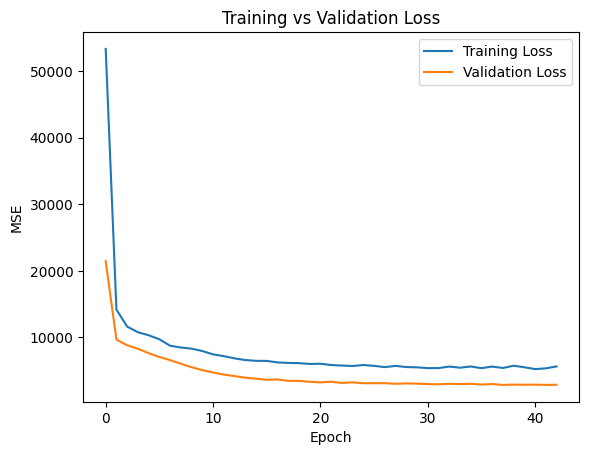

In [74]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [75]:
test_loss, test_mae = model.evaluate(X_test, y_test)

print("Test MSE:", test_loss)
print("Test MAE:", test_mae)

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 880us/step - loss: 2619.8945 - mae: 32.7537
Test MSE: 2619.89453125
Test MAE: 32.75374221801758


In [76]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test).flatten()

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 889us/step
R² Score: 0.9172632098197937
